# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets , transforms
from torch.utils.data import DataLoader

# Data prepairing

Here I am preparing the data for training the model.
First, I set up the transformations:
ToTensor() converts the image to a numerical format and normalizes the values to the range [0,1].
Lambda(view(-1)) flattens the 28x28 image into a vector of length 784,since the MLP takes a vector as input, not a matrix.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x : x.view(-1))
])
train_dataset = datasets.MNIST(root = './data' , train = True , download = True , transform = transform)

train_loader = DataLoader(train_dataset , batch_size = 32 , shuffle = True)

# MLP model

Here I define the architecture of the neural network (MLP).

I use a simple architecture:
input (784) → hidden layer (64) → output (10 classes).
This size is chosen as a compromise between speed and quality.

In [3]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784 , 64),
            nn.ReLU(),
            nn.Linear(64 , 10)
        )

    def forward(self , x):
        return self.net(x)
        

# Accuracy

This function evaluates the model's accuracy.

In [4]:
def evaluate(model, loader):
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            outputs = model(x)
            _, predicted = torch.max(outputs, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

    return correct / total

torch.no_grad() disables gradient calculation,since it is not needed during evaluation.This speeds up computations and reduces memory usage.

# Training function

This is the main function of training the model. I specifically made it universal so that different optimizers could be compared.

In [5]:
def train_model(optimizer_name, lr=0.01, epochs=10):
    model = MLP()
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr = 0.01)
    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr = 0.001)
    elif optimizer_name == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr = 0.001)

    loss_history = []
    acc_history = []

    for epoch in range(epochs):
        total_loss = 0

        for x, y in train_loader:
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss)

        acc = evaluate(model, train_loader)
        acc_history.append(acc)

    return loss_history, acc_history

# Testing

In [6]:
sgd_loss, sgd_acc = train_model("SGD")
adam_loss, adam_acc = train_model("Adam")
rms_loss, rms_acc = train_model("RMSprop")

# Plots

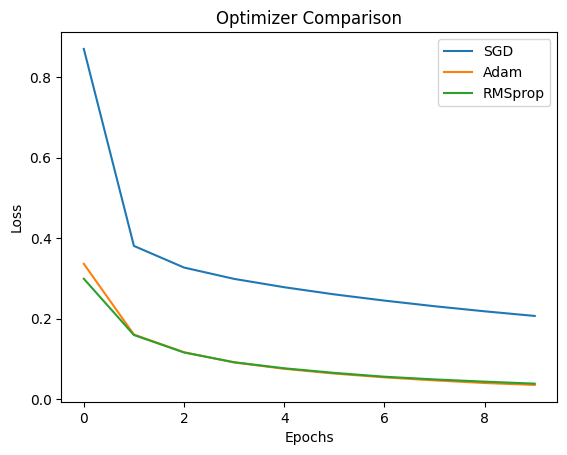

In [7]:
plt.plot(sgd_loss , label = 'SGD')
plt.plot(adam_loss , label = 'Adam')
plt.plot(rms_loss , label = 'RMSprop')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Optimizer Comparison")

plt.show()

Adam and RMSprop demonstrate fast convergence value of the loss function decreases sharply already in the first epochs. Their curves almost coincide, which indicates similar behavior of the algorithms. SGD converges significantly slower and remains at a higher loss level even by the end of training.

# Accuracy plot

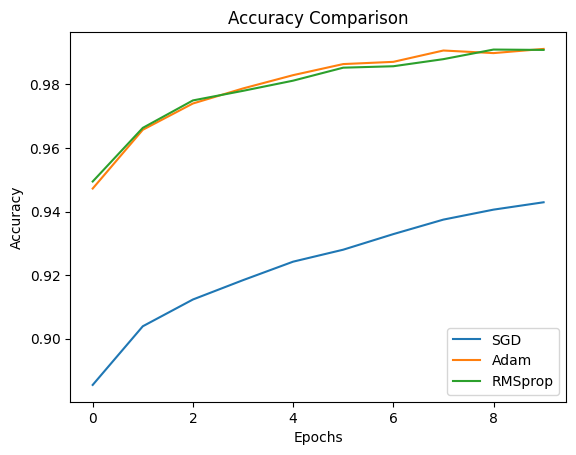

In [8]:
plt.plot(sgd_acc, label="SGD")
plt.plot(adam_acc, label="Adam")
plt.plot(rms_acc, label="RMSprop")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Comparison")

plt.show()

Adam and RMSprop achieve high accuracy (~99%) already by the 5th–7th epoch. Their curves are smooth and stable, without strong fluctuations. SGD shows slower accuracy growth and reaches about ~94%, which is lower than the others.